In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import pandas as pd

df = pd.read_excel('../dataset/PPPData_EN_1.0.xlsx', engine='openpyxl')
df.head()


,Count,ID,Short Description1,Cpvs,Cpvs Designation,Environmental criteria (T/F),Publication Year,Close Year,Country,Municipality,...,Contract end type,Number of bidders,Involves joint procurement (with several entities) (T/F),Awarded by a central purchasing body (T/F),Conclusion of a framework agreement (T/F),Electronic auction (T/F),Negotiation phase (T/F),Contracting by lots (T/F),Justification for deadline change,Justification for price change
0,0,9347658,Construction of the domestic and rainwater dra...,45231300-8,Construction work for water and sewage pipelines,False,2020.0,2022,Portugal,Almada,...,Complete fulfillment of the contract,4,0.0,0.0,0.0,0.0,0.0,NaN,"the project was finished ahead of schedule, ev...",price review
1,1,9331053,Repairs to Municipal Swimming Pools,45212290-5,Repair and maintenance work in connection with...,False,2020.0,2022,Portugal,Viseu,...,Complete fulfillment of the contract,2,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,2,9328338,Rehabilitation contract for the beachside ramp...,45262330-3,Concrete repair work,False,2022.0,2022,Portugal,Loulé,...,Complete fulfillment of the contract,5,NaN,NaN,NaN,NaN,NaN,NaN,completion of work carried out before the dead...,NaN
3,3,9305186,Rehabilitation of the Cavalo Bridge in Travass...,"45000000-7, 45221119-9","Construction work, Bridge renewal construction...",False,2020.0,2022,Portugal,Viseu,...,Complete fulfillment of the contract,5,0.0,0.0,0.0,0.0,0.0,0.0,"from 05/10/2021 to 06/15/2021 (37 days), due t...",complementary work
4,4,9286914,Replacement of the bridge in Moure de Madalena...,45221119-9,Bridge renewal construction work,False,2021.0,2022,Portugal,Viseu,...,Complete fulfillment of the contract,9,0.0,0.0,0.0,0.0,0.0,0.0,there was no change to the execution period,price review


In [2]:
df = pd.read_csv('../dataset/PPPData_Public_Contracts.csv', encoding='cp1252')
df.head()


UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 756: character maps to <undefined>

In [8]:
df1 = df.copy()

In [9]:
print("Dataset Shape:", df1.shape)
df1.describe

Dataset Shape: (5214, 38)


<bound method NDFrame.describe of       Count       ID                                 Short Description1  \
0         0  9347658  Construction of the domestic and rainwater dra...   
1         1  9331053                Repairs to Municipal Swimming Pools   
2         2  9328338  Rehabilitation contract for the beachside ramp...   
3         3  9305186  Rehabilitation of the Cavalo Bridge in Travass...   
4         4  9286914  Replacement of the bridge in Moure de Madalena...   
...     ...      ...                                                ...   
5209   5209   127711  The object of this contract is to carry out th...   
5210   5210   136794  The aim is to organize Largo 25 de Abril, with...   
5211   5211   132712  Exterior spaces of the eb1 school + ji das gal...   
5212   5212   102351  Remodeling of the Amieira do Tejo and Montalvã...   
5213   5213   134832  Execution contract for the Interceptor Systems...   

                        Cpvs  \
0                 45231300-8   
1

In [10]:
df1.isnull().sum()

Count                                                          0
ID                                                             0
Short Description1                                             0
Cpvs                                                           0
Cpvs Designation                                               0
Environmental criteria (T/F)                                   0
Publication Year                                              48
Close Year                                                     0
Country                                                        0
Municipality                                                 172
District                                                     168
District Code                                                152
Submission deadline (days)                                   302
Signing date                                                   0
Closing date                                                   0
Diference between close a

<h1>Removing NON-Applicable values</h1>

In [11]:
critical_columns = ['Submission deadline (days)', 'District Code', 'Base Bid Price (€)', 'Publication Year']
filtered_df = df1.dropna(subset=critical_columns)


In [12]:
for column in ['Publication Year', 'District Code', 'Submission deadline (days)', 'Base Bid Price (€)']:
    print(f"{column}: {df1[df1[column].isnull()].shape[0]} contracts removed")


Publication Year: 48 contracts removed
District Code: 152 contracts removed
Submission deadline (days): 302 contracts removed
Base Bid Price (€): 48 contracts removed


In [13]:
critical_columns = ['Submission deadline (days)', 'District Code', 'Base Bid Price (€)', 'Publication Year']
filtered_df = df1.dropna(subset=critical_columns)
excluded_count = df1.shape[0] - filtered_df.shape[0]
print(f"Total excluded contracts: {excluded_count}")


Total excluded contracts: 441


In [14]:
df1 = filtered_df.copy()
df1.shape

(4773, 38)

<h1>Encoding Categorical Data with LabelEncoder</h1>

In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df1['CPV Code'] = label_encoder.fit_transform(df1['Cpvs'])

print(df1[['Cpvs', 'CPV Code']].head())

                     Cpvs  CPV Code
0              45231300-8       181
2              45262330-3       354
3  45000000-7, 45221119-9         5
4              45221119-9       151
5              45221119-9       151


In [16]:
df1['Environmental criteria (T/F)'] = label_encoder.fit_transform(df1['Environmental criteria (T/F)'])

print(df1['Environmental criteria (T/F)'])

0       0
2       0
3       0
4       0
5       0
       ..
5208    0
5209    0
5210    0
5211    0
5212    0
Name: Environmental criteria (T/F), Length: 4773, dtype: int64


<h1>Creating Performance Class (Target Variable)</h1>

In [17]:
df1['EP/IP'] = df1['Effective Price (€)'] / df1['Initial price (€)'] * 100

# Use numpy.select for conditional logic
conditions = [
    df1['EP/IP'] >= 105,
    (df1['EP/IP'] > 95) & (df1['EP/IP'] < 105),
    df1['EP/IP'] <= 95
]
choices = ['Spill', 'Compliance', 'Savings']

df1['Performance Class'] = np.select(conditions, choices, default='Unknown')

# Check the resulting data
print(df1[['EP/IP', 'Performance Class']].head())

        EP/IP Performance Class
0  116.824669             Spill
2  100.000000        Compliance
3  100.000000        Compliance
4  100.000000        Compliance
5   90.537794           Savings


In [18]:
df1.dtypes

Count                                                         int64
ID                                                            int64
Short Description1                                           object
Cpvs                                                         object
Cpvs Designation                                             object
Environmental criteria (T/F)                                  int64
Publication Year                                            float64
Close Year                                                    int64
Country                                                      object
Municipality                                                 object
District                                                     object
District Code                                               float64
Submission deadline (days)                                  float64
Signing date                                                 object
Closing date                                    

In [19]:
# Select numeric columns (int64 and float64) from the dataset
numeric_columns = df1.select_dtypes(include=['int64', 'float64'])

# Include the 'Performance Class' column in the dataset
df2 = numeric_columns.copy()
df2['Performance Class'] = df1['Performance Class']
df2.rename(columns={
    'Classification of the multifactor criteria (%)': 'Weight of the price factor in award criteria'
}, inplace=True)
df2.rename(columns={"Base Bid Price (€)": "Base Tender Price"}, inplace=True)

In [20]:
df2.isnull().sum()

Count                                                          0
ID                                                             0
Environmental criteria (T/F)                                   0
Publication Year                                               0
Close Year                                                     0
District Code                                                  0
Submission deadline (days)                                     0
Diference between close and signing dates                      0
Execution deadline (days)                                      0
Base Tender Price                                              0
Initial price (€)                                              0
I. price Class                                                 0
Effective Price (€)                                            0
Difference between the effective and initial price (€)         0
Proportion between the effective and initial price (%)         0
Award criteria class     

<h1>Dropping Unwanted Columns</h1>

In [21]:
df2 = df2.drop(columns = ['Count', 'ID', 'Close Year', 'Diference between close and signing dates', 'Effective Price (€)',
                           'Difference between the effective and initial price (€)', 'Proportion between the effective and initial price (%)',
                           'EP/IP'])

In [22]:
df2.isnull().sum()

Environmental criteria (T/F)                                   0
Publication Year                                               0
District Code                                                  0
Submission deadline (days)                                     0
Execution deadline (days)                                      0
Base Tender Price                                              0
Initial price (€)                                              0
I. price Class                                                 0
Award criteria class                                           0
Weight of the price factor in award criteria                   1
Number of bidders                                              0
Involves joint procurement (with several entities) (T/F)    2790
Awarded by a central purchasing body (T/F)                  2790
Conclusion of a framework agreement (T/F)                   1341
Electronic auction (T/F)                                    1341
Negotiation phase (T/F)  

In [23]:
df2 = df2.dropna()

In [24]:
df2.isnull().sum()

Environmental criteria (T/F)                                0
Publication Year                                            0
District Code                                               0
Submission deadline (days)                                  0
Execution deadline (days)                                   0
Base Tender Price                                           0
Initial price (€)                                           0
I. price Class                                              0
Award criteria class                                        0
Weight of the price factor in award criteria                0
Number of bidders                                           0
Involves joint procurement (with several entities) (T/F)    0
Awarded by a central purchasing body (T/F)                  0
Conclusion of a framework agreement (T/F)                   0
Electronic auction (T/F)                                    0
Negotiation phase (T/F)                                     0
Contract

In [25]:
# Display the resulting dataset
df2.head()

,Environmental criteria (T/F),Publication Year,District Code,Submission deadline (days),Execution deadline (days),Base Tender Price,Initial price (€),I. price Class,Award criteria class,Weight of the price factor in award criteria,Number of bidders,Involves joint procurement (with several entities) (T/F),Awarded by a central purchasing body (T/F),Conclusion of a framework agreement (T/F),Electronic auction (T/F),Negotiation phase (T/F),Contracting by lots (T/F),CPV Code,Performance Class
3,0,2020.0,20.0,19.0,90,57900.0,42715.76,1,2,100.0,5,0.0,0.0,0.0,0.0,0.0,0.0,5,Compliance
4,0,2021.0,20.0,15.0,90,137030.0,41480.00,1,2,100.0,9,0.0,0.0,0.0,0.0,0.0,0.0,151,Compliance
5,0,2020.0,20.0,18.0,30,33378.0,24967.75,1,2,100.0,5,0.0,0.0,0.0,0.0,0.0,0.0,151,Savings
6,0,2021.0,20.0,18.0,90,40050.0,37849.69,1,2,100.0,4,0.0,0.0,0.0,0.0,0.0,0.0,175,Savings
12,0,2020.0,20.0,21.0,70,129880.0,111977.14,1,2,100.0,4,0.0,0.0,0.0,0.0,0.0,0.0,1,Spill


In [26]:
df2.columns

Index(['Environmental criteria (T/F)', 'Publication Year', 'District Code',
       'Submission deadline (days)', 'Execution deadline (days)',
       'Base Tender Price', 'Initial price (€)', 'I. price Class',
       'Award criteria class', 'Weight of the price factor in award criteria',
       'Number of bidders',
       'Involves joint procurement (with several entities) (T/F)',
       'Awarded by a central purchasing body (T/F)',
       'Conclusion of a framework agreement (T/F)', 'Electronic auction (T/F)',
       'Negotiation phase (T/F)', 'Contracting by lots (T/F)', 'CPV Code',
       'Performance Class'],
      dtype='object')

In [27]:
df2.shape

(1861, 19)

In [28]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Step 1: Encode the Target Variable
label_encoder = LabelEncoder()
df2['Performance Class'] = label_encoder.fit_transform(df2['Performance Class'])

# Step 2: Load Data and Split into Features and Target
X = df2.drop(columns=['Performance Class'])  # Exclude target column
y = df2['Performance Class']  # Encoded target variable

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts())

# Output the resampled dataset shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Optional: Check the label mapping for reference
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)

Class distribution before SMOTE:
Performance Class
0    878
2    256
1    112
Name: count, dtype: int64
X_train shape: (1246, 18)
y_train shape: (1246,)
Label Mapping: {'Compliance': 0, 'Savings': 1, 'Spill': 2}


<h1>DATA TREATMENT (SMOTE)</h1>

In [29]:
from imblearn.over_sampling import SMOTE

# Step 4: Apply SMOTE for Balancing
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 5: Check the Class Distribution After SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# Output the resampled dataset shapes
print("X_train_resampled shape:", X_train_resampled.shape)
print("y_train_resampled shape:", y_train_resampled.shape)

# Optional: Check the label mapping for reference
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)


Class distribution after SMOTE:
Performance Class
0    878
2    878
1    878
Name: count, dtype: int64
X_train_resampled shape: (2634, 18)
y_train_resampled shape: (2634,)
Label Mapping: {'Compliance': 0, 'Savings': 1, 'Spill': 2}


<h1>Feature Selection Methodology</h1>

<h2>Correlation Heatmap</h2>

Performance Class                                           1.000000
Base Tender Price                                           0.119375
Submission deadline (days)                                  0.105730
Initial price (€)                                           0.102633
I. price Class                                              0.085410
Publication Year                                            0.059080
Contracting by lots (T/F)                                   0.029417
Negotiation phase (T/F)                                     0.020168
Awarded by a central purchasing body (T/F)                  0.014257
Execution deadline (days)                                   0.013240
District Code                                               0.012134
Involves joint procurement (with several entities) (T/F)   -0.000015
Weight of the price factor in award criteria               -0.017065
Number of bidders                                          -0.017787
CPV Code                          

Text(0.5, 1.0, 'Top Correlated Features with Performance Class')

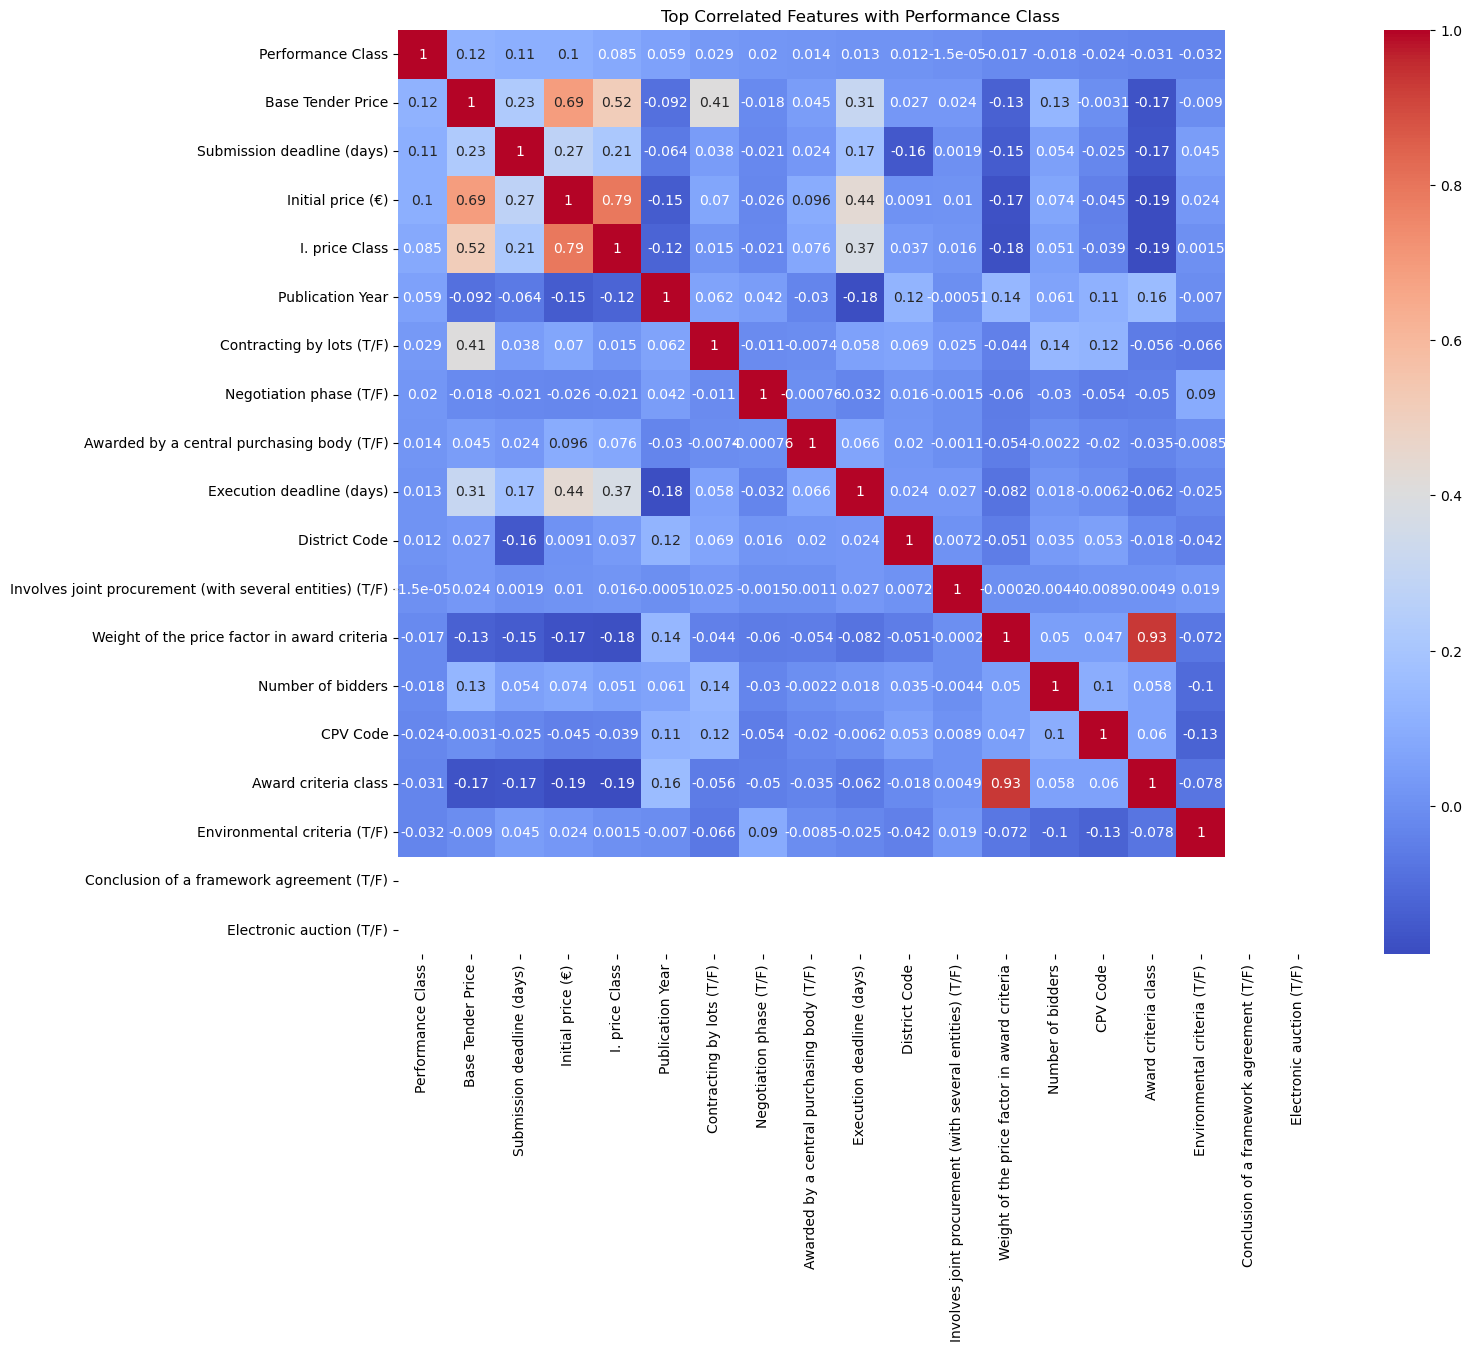

In [30]:
from sklearn.preprocessing import LabelEncoder
# Calculate the correlation matrix
correlations = df2.corr()

# Get correlations with the encoded target variable
performance_corr = correlations['Performance Class'].sort_values(ascending=False)
print(performance_corr)
plt.figure(figsize=(16, 12))

# Heatmap for features correlated with 'Finishing'
performance_corr_features = correlations.loc[performance_corr.index[:], performance_corr.index[:]]
sns.heatmap(performance_corr_features, annot=True, cmap='coolwarm', square=True)
plt.title('Top Correlated Features with Performance Class')


<h1>Feature Importance Analysis</h1>

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest on SMOTE-Resampled Data
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=33,        # Number of trees as in the research paper
    max_depth=4,            # Set to align with the paper's methodology
    max_features="sqrt",    # Use sqrt for max_features
    min_samples_split=2,    # Minimum samples required to split an internal node
    min_samples_leaf=2,     # Minimum samples at a leaf node
    bootstrap=False         # Disable bootstrapping as per the paper
)
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(bootstrap=False, max_depth=4, min_samples_leaf=2,
                       n_estimators=33, random_state=42)

<h2>Impurity-based feature importance</h2>


Impurity-Based Feature Importance:
                                              Feature  Importance
1                                    Publication Year    0.180204
3                          Submission deadline (days)    0.144721
4                           Execution deadline (days)    0.095340
0                        Environmental criteria (T/F)    0.095300
2                                       District Code    0.091587
9        Weight of the price factor in award criteria    0.085527
17                                           CPV Code    0.084537
5                                   Base Tender Price    0.080011
6                                   Initial price (€)    0.057986
8                                Award criteria class    0.056335
10                                  Number of bidders    0.013043
15                            Negotiation phase (T/F)    0.007585
7                                      I. price Class    0.004027
16                          Contracting 

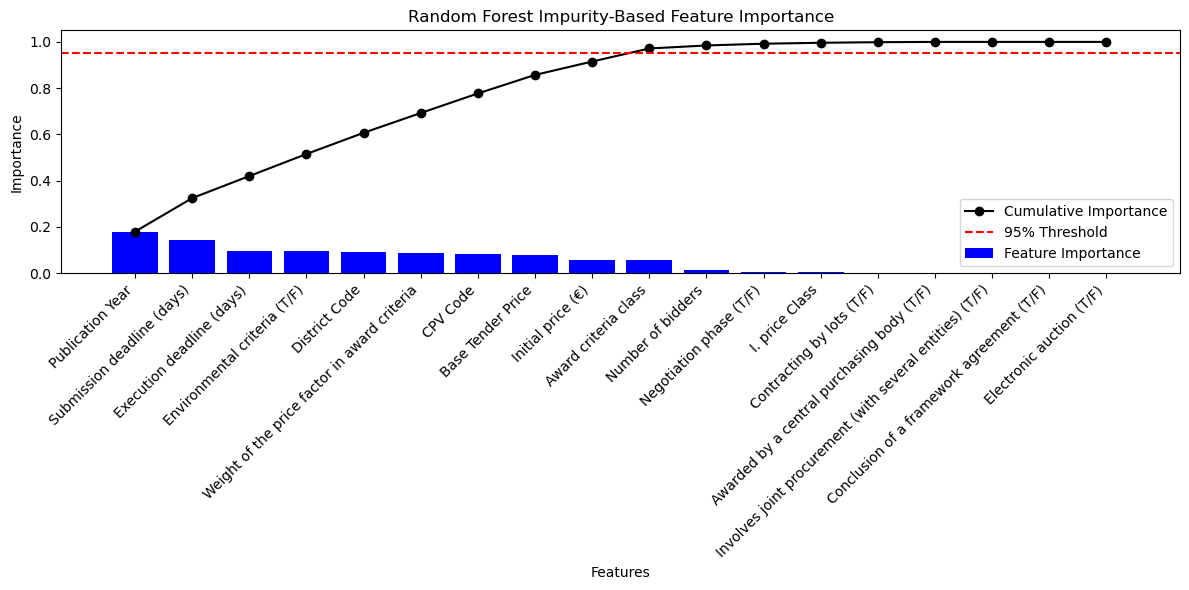

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate Impurity-Based Importance
impurity_importances = rf_model.feature_importances_

# Create a DataFrame for visualization
impurity_df = pd.DataFrame({
    "Feature": X_train_resampled.columns,  # Use original column names
    "Importance": impurity_importances
}).sort_values(by="Importance", ascending=False)

# Print Feature Importance Table
print("\nImpurity-Based Feature Importance:")
print(impurity_df)

# Plot Impurity-Based Feature Importance
plt.figure(figsize=(12, 6))
plt.bar(impurity_df["Feature"], impurity_df["Importance"], color="blue", label="Feature Importance")
plt.plot(impurity_df["Feature"], impurity_df["Importance"].cumsum(), color="black", marker="o", label="Cumulative Importance")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% Threshold")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Impurity-Based Feature Importance")
plt.legend()
plt.tight_layout()
plt.show()


<h2>Permutation-based feature importance</h2>


Permutation-Based Feature Importance:
                                              Feature    Importance
17                                           CPV Code  2.655827e-03
0                        Environmental criteria (T/F)  3.794038e-04
7                                      I. price Class  2.590520e-17
11  Involves joint procurement (with several entit...  0.000000e+00
12         Awarded by a central purchasing body (T/F)  0.000000e+00
13          Conclusion of a framework agreement (T/F)  0.000000e+00
14                           Electronic auction (T/F)  0.000000e+00
15                            Negotiation phase (T/F)  0.000000e+00
9        Weight of the price factor in award criteria -2.710027e-04
16                          Contracting by lots (T/F) -3.794038e-04
1                                    Publication Year -1.626016e-03
10                                  Number of bidders -3.252033e-03
2                                       District Code -7.046070e-03
8        

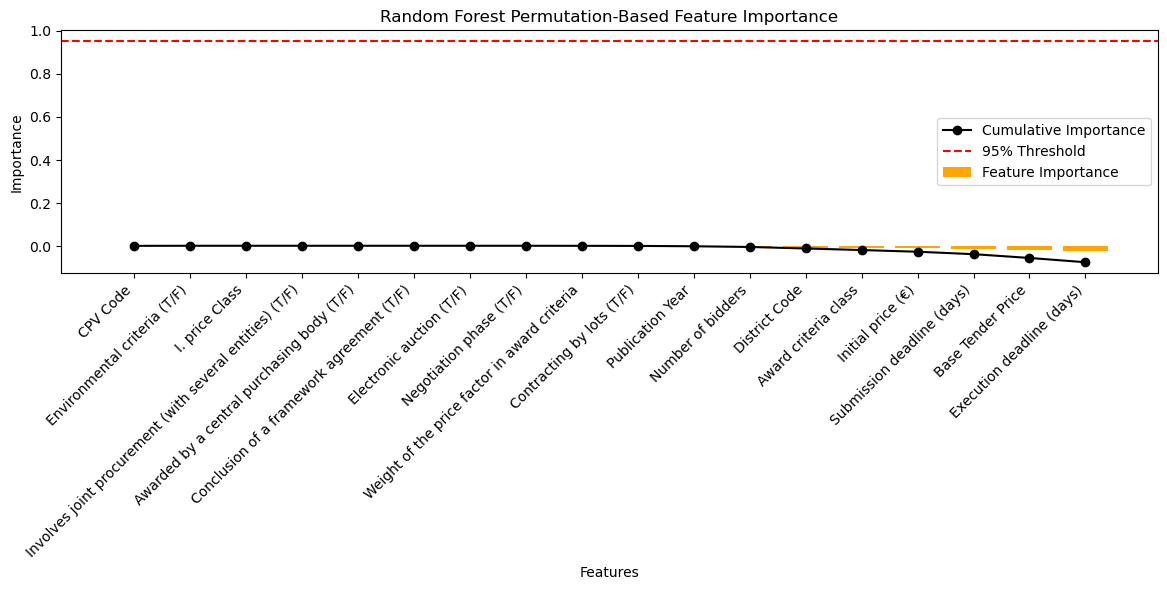

In [33]:
from sklearn.inspection import permutation_importance

# Perform Permutation Importance on Test Data
perm_importance = permutation_importance(rf_model, X_test, y_test, n_repeats=30, random_state=42)

# Create a DataFrame for Permutation Importance
perm_df = pd.DataFrame({
    "Feature": X_train_resampled.columns,
    "Importance": perm_importance["importances_mean"]
}).sort_values(by="Importance", ascending=False)

# Print Permutation Importance Table
print("\nPermutation-Based Feature Importance:")
print(perm_df)

# Plot Permutation-Based Feature Importance
plt.figure(figsize=(12, 6))
plt.bar(perm_df["Feature"], perm_df["Importance"], color="orange", label="Feature Importance")
plt.plot(perm_df["Feature"], perm_df["Importance"].cumsum(), color="black", marker="o", label="Cumulative Importance")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% Threshold")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Permutation-Based Feature Importance")
plt.legend()
plt.tight_layout()
plt.show()


<h1>Hyperparameter Tuning with GridSearchCV</h1>

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 8, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', 'balanced_subsample'],
    'max_features': ['sqrt', 'log2', 0.5, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_resampled, y_train_resampled)
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


<h1>Feature Selection</h1>

In [35]:
selected_features = [
    "Publication Year",                        # High importance
    "Weight of the price factor in award criteria",  # Preferred over "Award Criteria Class"
    "CPV Code",                               # High importance
    "District Code",                          # Moderate importance
    "Base Tender Price",                      # Preferred over "Initial Price (€)"
    "Submission deadline (days)",            # Moderate importance
    "Execution deadline (days)",             # Moderate importance
    "Number of bidders"                      # Retained due to relevance
]

# Step 2: Apply Feature Selection to Training and Test Sets
X_train_resampled = X_train_resampled[selected_features]
X_test = X_test[selected_features]

# Verify Feature Alignment
print("Features in X_train_resampled:", X_train_resampled.columns.tolist())
print("Features in X_test:", X_test.columns.tolist())

Features in X_train_resampled: ['Publication Year', 'Weight of the price factor in award criteria', 'CPV Code', 'District Code', 'Base Tender Price', 'Submission deadline (days)', 'Execution deadline (days)', 'Number of bidders']
Features in X_test: ['Publication Year', 'Weight of the price factor in award criteria', 'CPV Code', 'District Code', 'Base Tender Price', 'Submission deadline (days)', 'Execution deadline (days)', 'Number of bidders']


<h1>Class-Overlap Analysis</h1>

In [36]:
from scipy.stats import ks_2samp, f_oneway

# Define target variable and selected features
target_col = "Performance Class"  # Update with your actual column name if different
selected_features =  selected_features # Replace with your selected features

# Ensure categorical encoding of the target variable
df2[target_col] = df2[target_col].astype(str)



In [37]:
# Function to compute Bhattacharyya Coefficient
def bhattacharyya_coefficient(class1, class2):
    hist1, bins1 = np.histogram(class1, bins=20, density=True)
    hist2, bins2 = np.histogram(class2, bins=20, density=True)
    
    # Normalize distributions
    hist1 = hist1 / np.sum(hist1)
    hist2 = hist2 / np.sum(hist2)
    
    # Compute coefficient (higher values = more overlap)
    bc = np.sum(np.sqrt(hist1 * hist2))
    return bc


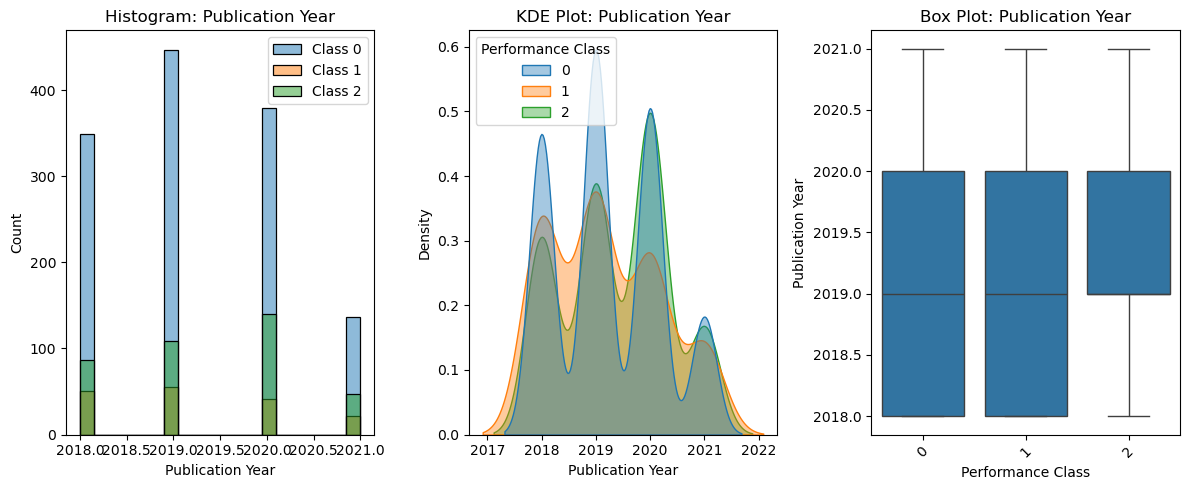

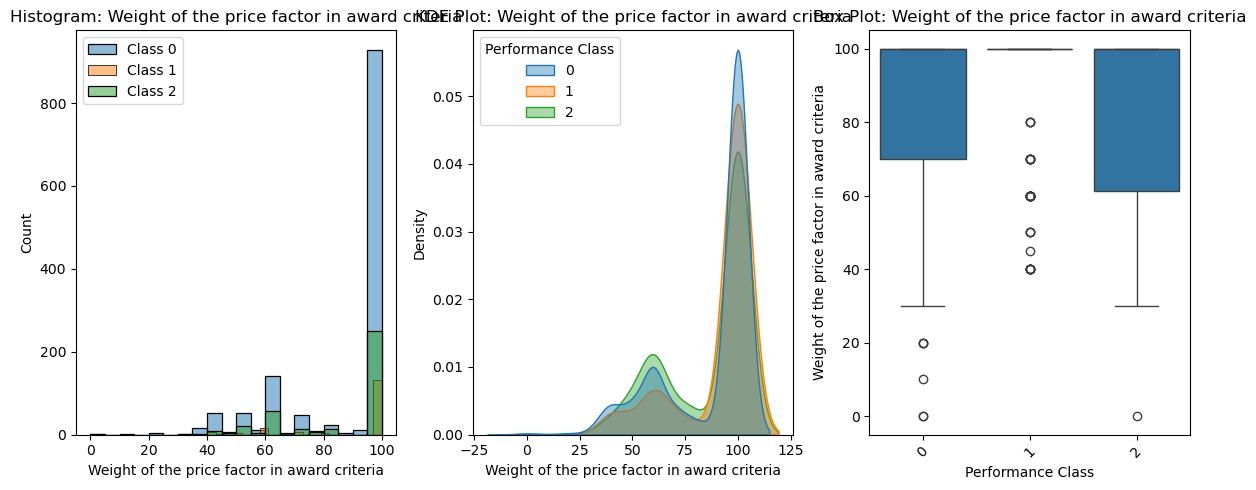

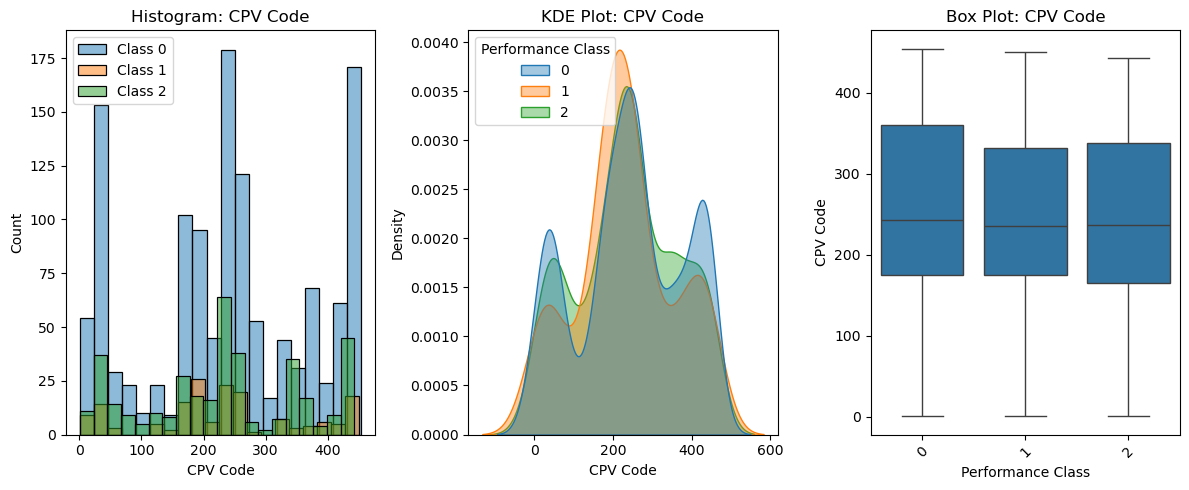

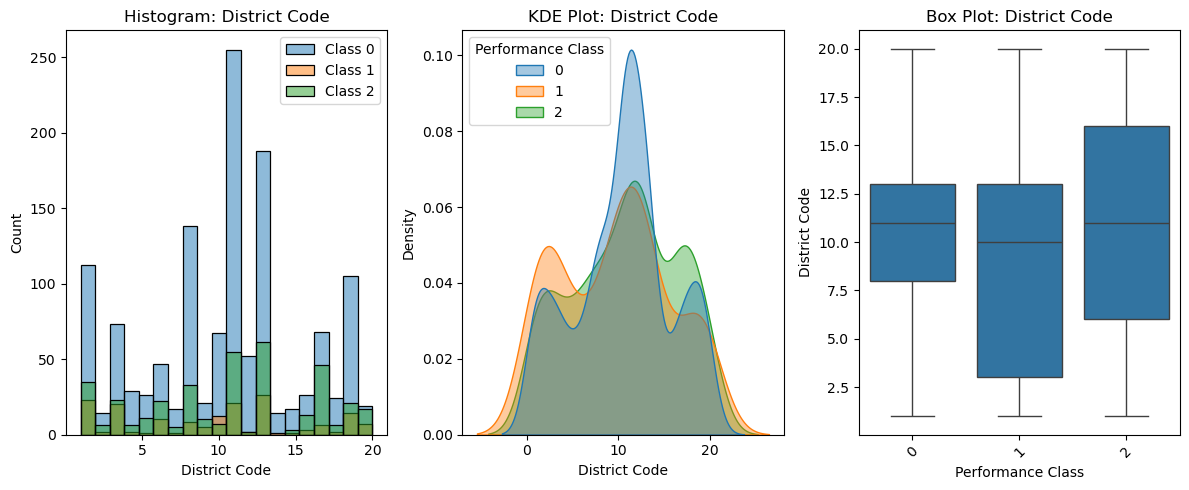

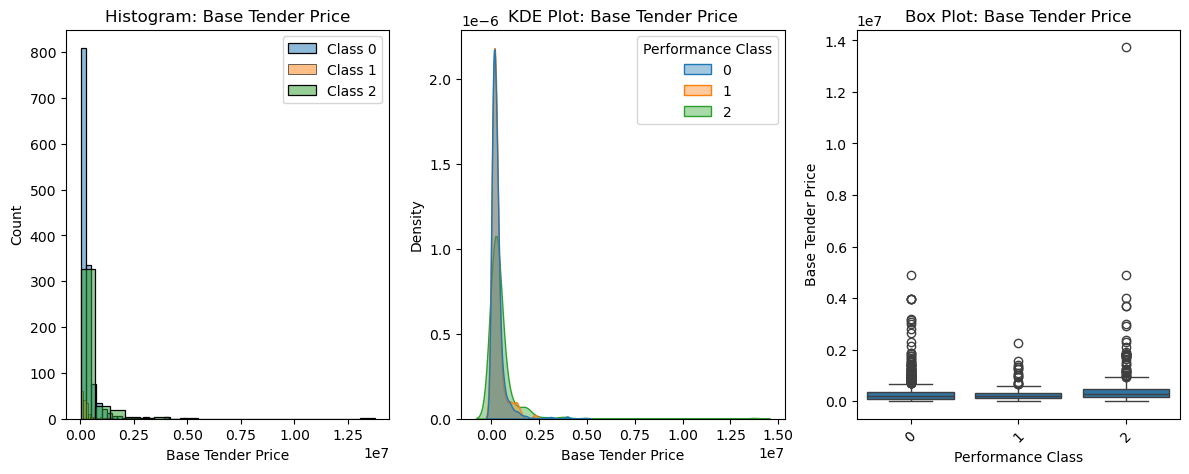

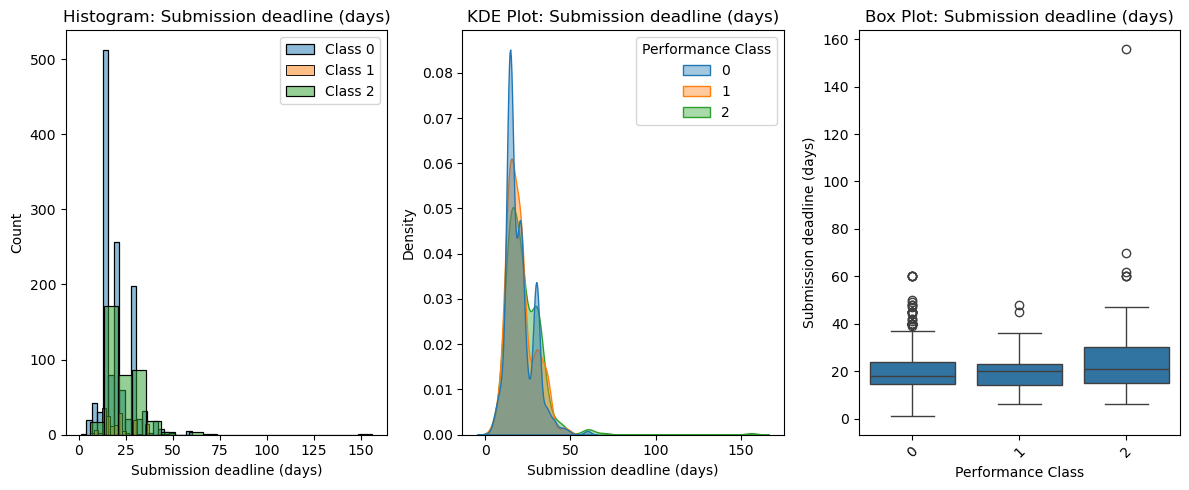

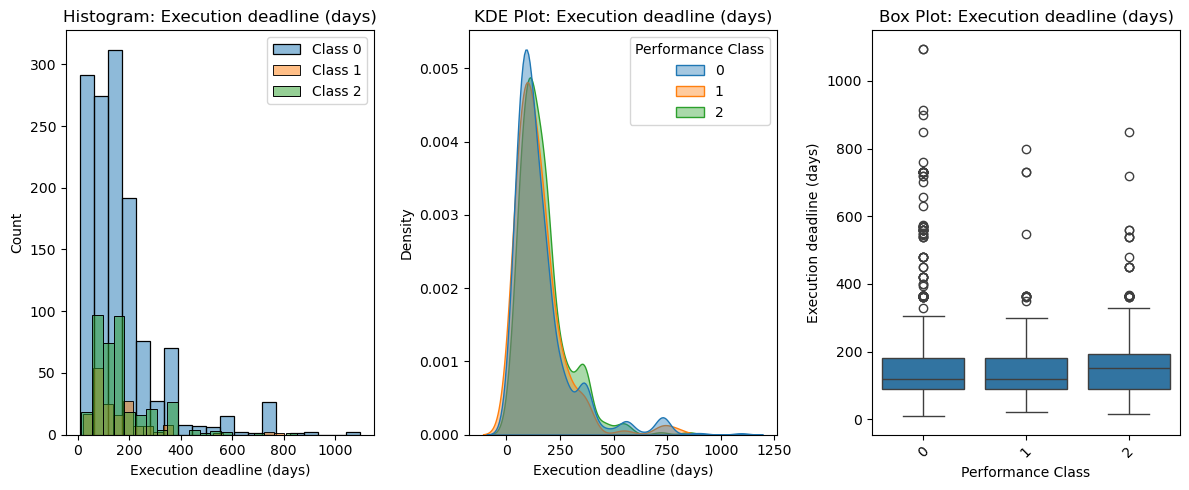

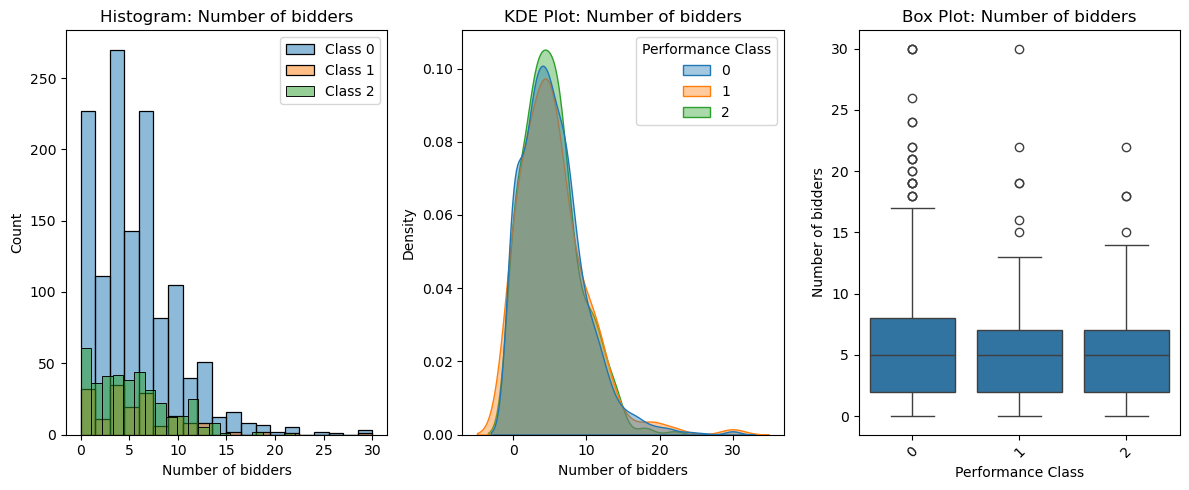

In [38]:
for feature in selected_features:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 3, 1)
    for label in df2[target_col].unique():
        sns.histplot(df2[df2[target_col] == label][feature], kde=False, label=f'Class {label}', alpha=0.5, bins=20)
    plt.title(f'Histogram: {feature}')
    plt.legend()

    # KDE Plot
    plt.subplot(1, 3, 2)
    sns.kdeplot(data=df2, x=feature, hue=target_col, fill=True, common_norm=False, alpha=0.4)
    plt.title(f'KDE Plot: {feature}')
    
    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(data=df2, x=target_col, y=feature)
    plt.title(f'Box Plot: {feature}')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


In [39]:
    unique_classes = df2[target_col].unique()
    for i in range(len(unique_classes)):
        for j in range(i+1, len(unique_classes)):
            class1 = df2[df2[target_col] == unique_classes[i]][feature].dropna()
            class2 = df2[df2[target_col] == unique_classes[j]][feature].dropna()
            bc_value = bhattacharyya_coefficient(class1, class2)
            print(f"Bhattacharyya Coefficient between {unique_classes[i]} and {unique_classes[j]} for {feature}: {bc_value:.4f}")


Bhattacharyya Coefficient between 0 and 1 for Number of bidders: 0.9853
Bhattacharyya Coefficient between 0 and 2 for Number of bidders: 0.9597
Bhattacharyya Coefficient between 1 and 2 for Number of bidders: 0.9299


In [40]:
    # Kolmogorov-Smirnov (KS) Test for class separability
    if len(unique_classes) > 1:
        ks_stats = [ks_2samp(df2[df2[target_col] == c1][feature].dropna(), df2[df2[target_col] == c2][feature].dropna())
                    for c1, c2 in zip(unique_classes[:-1], unique_classes[1:])]
        for idx, stat in enumerate(ks_stats):
            print(f"KS Test between {unique_classes[idx]} and {unique_classes[idx+1]} for {feature}: D={stat.statistic:.4f}, p={stat.pvalue:.4f}")


KS Test between 0 and 1 for Number of bidders: D=0.0355, p=0.9884
KS Test between 1 and 2 for Number of bidders: D=0.0342, p=0.9983


In [41]:
    # ANOVA test (if more than 2 classes)
    if len(unique_classes) > 2:
        anova_groups = [df2[df2[target_col] == label][feature].dropna() for label in unique_classes]
        f_stat, p_value = f_oneway(*anova_groups)
        print(f"ANOVA Test for {feature}: F={f_stat:.4f}, p={p_value:.4f}")


ANOVA Test for Number of bidders: F=0.3633, p=0.6954


<h1>RandomForest Model</h1>

In [44]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, f1_score


# Step 1: Prepare Features and Target
X = df2[selected_features]
y = df2["Performance Class"]

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Step 3: Train Random Forest Model
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=None,
    class_weight="balanced_subsample",
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
)

rf_model.fit(X_train_resampled, y_train_resampled)


# Step 4: Evaluate the Model
y_test_rf = y_test.astype(str)  
y_pred_rf = rf_model.predict(X_test)  
y_pred_rf = y_pred_rf.astype(str)  

# Now evaluate
accuracy = accuracy_score(y_test_rf, y_pred_rf)
precision = precision_score(y_test_rf, y_pred_rf, average="weighted")
recall = recall_score(y_test_rf, y_pred_rf, average="weighted")
f1score = f1_score(y_test_rf, y_pred_rf, average="weighted")

print(f"Test Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1-Score (Weighted): {f1score:.2f}")

print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_rf))



Test Accuracy: 0.88
Precision (Weighted): 0.88
Recall (Weighted): 0.88
F1-Score (Weighted): 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       421
           1       0.90      0.62      0.74        61
           2       0.86      0.76      0.81       133

    accuracy                           0.88       615
   macro avg       0.88      0.78      0.82       615
weighted avg       0.88      0.88      0.88       615



<h1>Randomized Search CV</h1>

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'C': 3.845401188473625, 'gamma': 0.9607143064099162, 'kernel': 'rbf'}
Test Accuracy: 0.49
Precision (Weighted): 0.58
Recall (Weighted): 0.49
F1-Score (Weighted): 0.52

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.54      0.62      1108
           1       0.21      0.36      0.26       211
           2       0.23      0.36      0.28       256

    accuracy                           0.49      1575
   macro avg       0.39      0.42      0.39      1575
weighted avg       0.58      0.49      0.52      1575



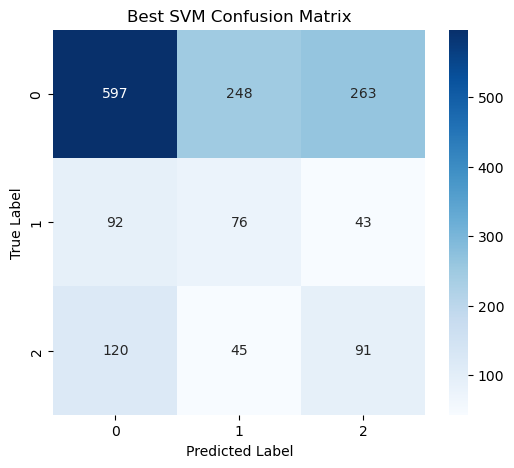

In [225]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Define optimized parameter grid
param_dist = {
    'C': uniform(0.1, 10),  # Smaller range to speed up training
    'gamma': uniform(0.01, 1),  # Lower gamma to prevent slow convergence
    'kernel': ['rbf', 'linear']  # Remove 'poly' and 'sigmoid' for speed
}

# Initialize the SVM model
svm_model = SVC()

# Perform Randomized Search with optimizations
random_search = RandomizedSearchCV(
    svm_model, param_distributions=param_dist,
    n_iter=10,  # Reduce iterations for faster results
    cv=3,  # Reduce cross-validation folds
    scoring='f1_weighted',
    n_jobs=-1,  # Use all CPU cores
    random_state=42,
    verbose=1  # Show progress
)

# Fit on a subset first (20% of training data)
X_train_subset, _, y_train_subset, _ = train_test_split(X_train_resampled, y_train_svm, train_size=0.2, random_state=42)
random_search.fit(X_train_subset, y_train_subset)

# Best hyperparameters
print("Best Parameters:", random_search.best_params_)

# Evaluate on full test data
best_svm_model = random_search.best_estimator_
y_pred_svm = best_svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test_svm, y_pred_svm)
precision = precision_score(y_test_svm, y_pred_svm, average="weighted")
recall = recall_score(y_test_svm, y_pred_svm, average="weighted")
f1score = f1_score(y_test_svm, y_pred_svm, average="weighted")

print(f"Test Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1-Score (Weighted): {f1score:.2f}")

print("\nClassification Report:")
print(classification_report(y_test_svm, y_pred_svm))

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(pd.crosstab(y_test_svm, y_pred_svm), annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test_svm), yticklabels=np.unique(y_test_svm))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Best SVM Confusion Matrix")
plt.show()


<h1>One Class SVM</h1>

/Users/adnansmacbookair/anaconda3/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Test Accuracy: 0.70
Precision (Weighted): 0.49
Recall (Weighted): 0.70
F1-Score (Weighted): 0.58

Classification Report:
              precision    recall  f1-score   support

           0       0.70      1.00      0.83      1108
           1       0.00      0.00      0.00       211
           2       0.00      0.00      0.00       256

    accuracy                           0.70      1575
   macro avg       0.23      0.33      0.28      1575
weighted avg       0.49      0.70      0.58      1575



/Users/adnansmacbookair/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/adnansmacbookair/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/adnansmacbookair/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/a

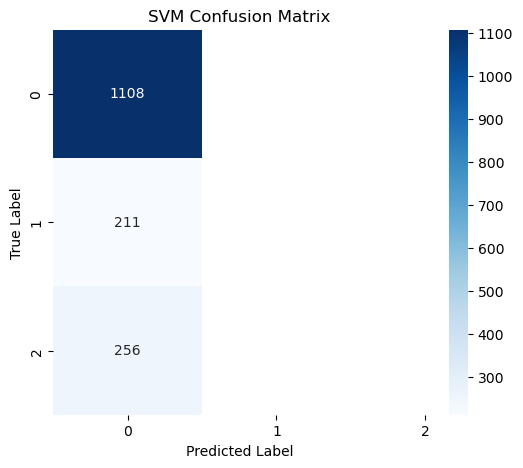

In [239]:
# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 2: Prepare Features and Target
X = df2[selected_features]
y = df2["Performance Class"]

# Step 3: Train-Test Split (Same as RandomForest)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

# **Apply Fix Locally for SVM Only**
y_train_svm = y_train_resampled.astype(str)  # Convert only for SVM training
y_test_svm = y_test.astype(str)  # Convert only for SVM testing

# Step 5: Standardize the Data (SVM is sensitive to feature scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)  # Use the resampled training data
X_test_scaled = scaler.transform(X_test)  # Scale the test data

# Step 6: Train SVM Model
svm_model = SVC(kernel="rbf", C=1.0, gamma=0.961, class_weight="balanced")
svm_model.fit(X_train_scaled, y_train_svm)


# Step 7: Evaluate the Model
y_pred_svm = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test_svm, y_pred_svm)
precision = precision_score(y_test_svm, y_pred_svm, average="weighted")
recall = recall_score(y_test_svm, y_pred_svm, average="weighted")
f1score = f1_score(y_test_svm, y_pred_svm, average="weighted")

print(f"Test Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1-Score (Weighted): {f1score:.2f}")

print("\nClassification Report:")
print(classification_report(y_test_svm, y_pred_svm))

# Step 8: Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(pd.crosstab(y_test_svm, y_pred_svm), annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test_svm), yticklabels=np.unique(y_test_svm))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")
plt.show()
